## Setup

In [1]:
import os

os.chdir("..")

In [ ]:
import yaml
import pandas as pd
from promptolution.llms import APILLM

from src.agent_tools.base import get_tools
from src.prompt_structures import AgentPromptBatch, AgentPromptSet
from src.mas import MASPredictor

In [7]:
config_path = "configs/setups/gsm8k.yaml"
run_dir = "results/main_experiments/dataset_gsm8k_optimizer_cantante_seed_42"

In [8]:
llm = APILLM(
    model_id="qwen-30b-a3b-llmlb",
    api_url="https://openwebui.uni-freiburg.de/api",
    api_key=open("token.txt").read().strip(),
)

In [9]:
llm.get_response("We working fine here?:)")

["Hey! I'm doing great, thanks for asking! 😊 I'm here and ready to help you with whatever you need. What's on your mind today?"]

In [10]:
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

tools_adapter = get_tools("gsm8k")

In [11]:
history_path = f"{run_dir}/prompts_per_step.parquet"
hist_df = pd.read_parquet(history_path)

In [12]:

agent_prompt_batch_strs = hist_df.prompt.tail(1)
apb = AgentPromptBatch.from_iterable(
    [AgentPromptSet.from_string(aps) for aps in agent_prompt_batch_strs]
)
api_key = open("token.txt").read().strip()
model_kwargs = dict(
    api_key=api_key,
    model_provider="openai",
    requests_per_second=5,
    max_bucket_size=5,
    model="qwen-30b-a3b-llmlb",
    base_url="https://openwebui.uni-freiburg.de/api",
    temperature=0.1,
    timeout=10,
    max_retries=1,
    max_tokens=512
)
predictor = MASPredictor(
    config,
    model_kwargs,
    tool_adapter=tools_adapter,
)

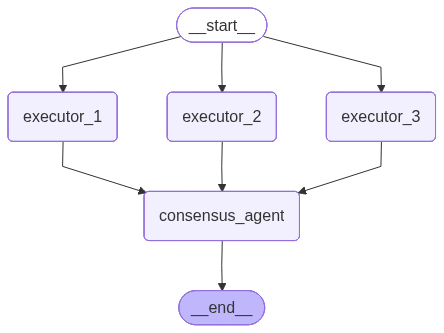

In [13]:
predictor.graph

In [15]:
for agent, prompt in eval(agent_prompt_batch_strs.item()).items():
    print(f"=== {agent} ===")
    print(prompt.encode("utf-8", "ignore").decode("utf-8"))
    print()

=== executor_1 ===
Please follow the steps below to solve the mathematical query:

1. Read the `{query}` carefully.  
2. If `` are present, examine them inside the `

Query: `{query}`

--- Output ---
Return exactly two XML elements:

```xml
<proposal_1>NUMERIC_ANSWER</proposal_1>
<justification_1>STEP_BY_STEP_REASONING</justification_1>
```

The `<proposal_1>` element must contain **only** the numeric answer—no units or additional text.  
The `<justification_1>` element should contain a clear, step‑by‑step justification.

=== executor_2 ===
Hello! 

**Task:** Work through the supplied mathematical query using a step‑by‑step reasoning process. You are one of three parallel solvers (executor_1, executor_2, executor_3); each will independently generate a solution that will later be merged by a consensus agent.

**Input:**  
**Query:** {query}  
**Examples:** 

**Output:** Produce a numeric answer together with a brief justification, formatted exactly as follows:

```xml
<proposal_2>NUMBER

# Inference

In [16]:
query = "What is the square root of 2209?"
result, h = predictor.predict([query], apb)
result[0]

MAS predict: 100%|██████████| 1/1 [00:04<00:00,  4.43s/it]


'47'

In [17]:
agents = [
    "justification_1",
    "proposal_1",
    "justification_2",
    "proposal_2",
    "justification_3",
    "proposal_3",
    "prediction",
]
for agent in agents:
    print(f"=== {agent} ===")
    print(h[0][agent])
    print()

=== justification_1 ===
To find the square root of 2209, we look for a number that, when squared, equals 2209. We can estimate by noting that:  
- 40² = 1600  
- 50² = 2500  

Since 2209 is between 1600 and 2500, the square root is between 40 and 50.  
Try 45² = 2025 (too low)  
Try 46² = 2116 (still low)  
Try 47² = 47 × 47 = (40 + 7)² = 40² + 2×40×7 + 7² = 1600 + 560 + 49 = 2209  

Since 47² = 2209, the square root of 2209 is 47.

=== proposal_1 ===
47

=== justification_2 ===
47 squared is 2209, as calculated: 47 × 47 = 2209. Therefore, the square root of 2209 is 47.

=== proposal_2 ===
47

=== justification_3 ===
The square root of 2209 is found by identifying a number that, when squared, equals 2209. Testing 47: 47 × 47 = (40 + 7) × (40 + 7) = 40² + 2×40×7 + 7² = 1600 + 560 + 49 = 2209. Thus, √2209 = 47.

=== proposal_3 ===
47

=== prediction ===
47

